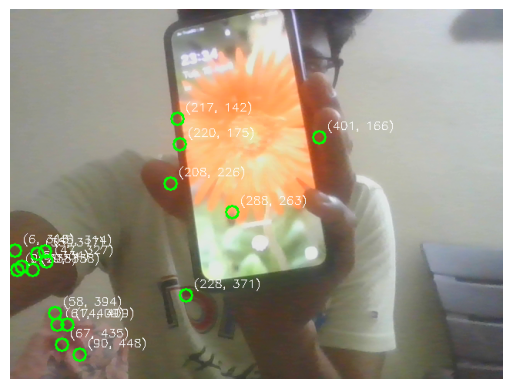

Laser dot found at: (401, 166)


In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from IPython.display import display, clear_output

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        print("Camera error.")
        break

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    lower_red = np.array([0, 100, 100])
    upper_red = np.array([10, 255, 255])
    mask = cv2.inRange(hsv, lower_red, upper_red)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    laser_dot = None

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > 5:
            M = cv2.moments(cnt)
            if M["m00"] != 0:
                cX = int(M["m10"] / M["m00"])
                cY = int(M["m01"] / M["m00"])
                laser_dot = (cX, cY)
                cv2.circle(frame, (cX, cY), 8, (0, 255, 0), 2)
                cv2.putText(frame, f"({cX}, {cY})", (cX + 10, cY - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    # Convert BGR to RGB for matplotlib
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    clear_output(wait=True)
    plt.imshow(frame_rgb)
    plt.axis('off')
    plt.show()

    if laser_dot:
        print(f"Laser dot found at: {laser_dot}")

    # Stop after a few frames to prevent infinite loop
    key = input("Press Enter to continue, or type 'q' to quit: ")
    if key.lower() == 'q':
        break

cap.release()


In [1]:
import math

# Known values
image_width = 640              # pixels
fov_deg = 73.74                # degrees (from earlier calculation)
baseline_cm = 3.0              # cm between camera and laser
laser_x = 401                  # pixel x-position of laser dot

# Step 1: Calculate pixel offset from center
pixel_offset = laser_x - (image_width / 2)  # how far laser dot is from center
pixels_per_degree = image_width / fov_deg  # conversion factor

# Step 2: Get angle in degrees
angle_deg = pixel_offset / pixels_per_degree
angle_rad = math.radians(angle_deg)

# Step 3: Use triangulation to get distance to wall
# tan(angle) = opposite / adjacent --> adjacent = baseline / tan(angle)
if angle_rad != 0:
    distance_cm = baseline_cm / math.tan(abs(angle_rad))
    print(f"Estimated distance to wall: {distance_cm:.2f} cm")
else:
    print("Laser is centered, cannot triangulate.")


Estimated distance to wall: 18.25 cm


📸 Starting Laser Distance Detection...


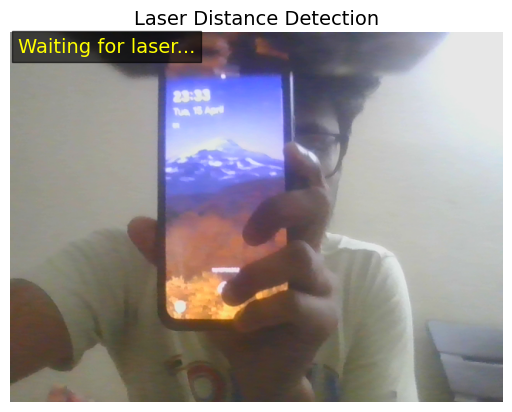

❌ No red laser dot found.
🔴 Distance: 43.81 cm
🔴 Distance: 13.09 cm
🔴 Distance: 40.25 cm
🔴 Distance: 42.55 cm
🔴 Distance: 39.18 cm
🔴 Distance: 43.81 cm
🔴 Distance: 13.09 cm
🔴 Distance: 62.11 cm
🔴 Distance: 33.06 cm
🔴 Distance: 35.44 cm
🔴 Distance: 18.97 cm
🔴 Distance: 17.38 cm
🔴 Distance: 17.38 cm
🔴 Distance: 37.22 cm
🔴 Distance: 17.38 cm
🔴 Distance: 40.25 cm
🔴 Distance: 24.33 cm
🔴 Distance: 22.82 cm
🔴 Distance: 17.17 cm
🔴 Distance: 36.30 cm
🔴 Distance: 23.94 cm
🔴 Distance: 41.37 cm
🔴 Distance: 37.22 cm
🔴 Distance: 35.44 cm
🔴 Distance: 45.14 cm
🔴 Distance: 39.18 cm
🔴 Distance: 26.53 cm
🔴 Distance: 36.30 cm
🔴 Distance: 16.21 cm
🔴 Distance: 16.78 cm
🔴 Distance: 28.58 cm
🔴 Distance: 32.34 cm
🔴 Distance: 17.17 cm
🔴 Distance: 30.35 cm
🔴 Distance: 22.13 cm
🔴 Distance: 26.53 cm
🔴 Distance: 36.30 cm
🔴 Distance: 36.30 cm
🔴 Distance: 16.58 cm
🔴 Distance: 35.44 cm
🔴 Distance: 38.17 cm
🔴 Distance: 29.15 cm
🔴 Distance: 23.55 cm
🔴 Distance: 38.17 cm
🔴 Distance: 35.44 cm
🔴 Distance: 43.81 cm
🔴 Distan

KeyboardInterrupt: 

In [1]:
import cv2
import numpy as np
import math
import time
import matplotlib.pyplot as plt

# === CONFIGURATION ===
baseline_cm = 3.0                # Distance between camera and laser
fov_deg = 73.74                  # Field of view in degrees
frame_width = 640
frame_height = 480
pixels_per_degree = frame_width / fov_deg

# === CAMERA SETUP ===
cap = cv2.VideoCapture(0)
cap.set(3, frame_width)
cap.set(4, frame_height)

def calculate_distance(laser_x):
    center_x = frame_width / 2
    pixel_offset = laser_x - center_x
    angle_deg = pixel_offset / pixels_per_degree
    angle_rad = math.radians(angle_deg)
    if angle_rad != 0:
        return baseline_cm / math.tan(abs(angle_rad))
    return None

# === MATPLOTLIB SETUP ===
plt.ion()  # Interactive mode ON
fig, ax = plt.subplots()

print("📸 Starting Laser Distance Detection...")

last_distance = "Waiting for laser..."

while True:
    ret, frame = cap.read()
    if not ret:
        break

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    lower_red = np.array([0, 150, 150])
    upper_red = np.array([10, 255, 255])
    mask = cv2.inRange(hsv, lower_red, upper_red)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    distance = None

    if contours:
        largest = max(contours, key=cv2.contourArea)
        M = cv2.moments(largest)
        if M["m00"] > 0:
            cX = int(M["m10"] / M["m00"])
            cY = int(M["m01"] / M["m00"])
            distance = calculate_distance(cX)

            # Draw laser dot
            cv2.circle(frame, (cX, cY), 8, (0, 255, 0), -1)
            cv2.putText(frame, f"Laser: ({cX}, {cY})", (cX + 10, cY - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

            if distance:
                distance_str = f"Distance: {distance:.2f} cm"
                cv2.putText(frame, distance_str, (cX + 10, cY + 20),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
                last_distance = distance_str
                print(f"🔴 {distance_str}")
    else:
        print("❌ No red laser dot found.")

    # === DISPLAY FRAME WITH MATPLOTLIB ===
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    ax.clear()
    ax.imshow(frame_rgb)
    ax.set_title("Laser Distance Detection", fontsize=14)
    ax.axis('off')

    # Display current distance as persistent overlay text
    ax.text(10, 25, last_distance, color='yellow', fontsize=14,
            bbox=dict(facecolor='black', alpha=0.6))

    plt.pause(0.01)

# === CLEANUP ===
cap.release()
plt.ioff()
plt.close()
